Module 6 : Geographic Category Insights

# Objective

The objective of this module is to analyze the geographic distribution of IT support tickets and evaluate regional performance using data visualization techniques. It focuses on identifying ticket concentration, mapping issue categories geographically, and analyzing the relationship between cluster size and performance metrics.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [20]:
df = pd.read_csv("../data/processed/cleaned_IT_Support_Tickets.csv")

df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score,Latitude,Longitude
0,Tkt000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,Cl001,Network,...,1,L1,Apac,Laptop,Ubuntu,Resolved After Troubleshooting.,89.333333,4,51.1657,10.4515
1,Tkt000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,Cl002,Login,...,2,L2,Emea,Laptop,Windows 11,Resolved After Troubleshooting.,105.550000,3,20.5937,78.9629
2,Tkt000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,Usa,Cl003,Software,...,2,L2,Emea,Desktop,Macos,Resolved After Troubleshooting.,15.933333,2,37.0902,-95.7129
3,Tkt000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,Cl001,Software,...,2,L3,Emea,Laptop,Ubuntu,Resolved After Troubleshooting.,50.200000,3,51.1657,10.4515
4,Tkt000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,Cl001,Login,...,2,L3,NaN,Desktop,Ubuntu,Resolved After Troubleshooting.,105.516667,4,56.1304,-106.3468


In [21]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score', 'Latitude', 'Longitude'],
      dtype='str')

In [23]:
country_coordinates = {
    "Germany": (51.1657, 10.4515),
    "India": (20.5937, 78.9629),
    "Usa": (37.0902, -95.7129),
    "Canada": (56.1304, -106.3468),
    "Uk": (55.3781, -3.4360)
}

df["Latitude"] = df["Country"].map(lambda x: country_coordinates[x][0])
df["Longitude"] = df["Country"].map(lambda x: country_coordinates[x][1])

df[["Country","Latitude","Longitude"]].head()

,Country,Latitude,Longitude
0,Germany,51.1657,10.4515
1,India,20.5937,78.9629
2,Usa,37.0902,-95.7129
3,Germany,51.1657,10.4515
4,Canada,56.1304,-106.3468


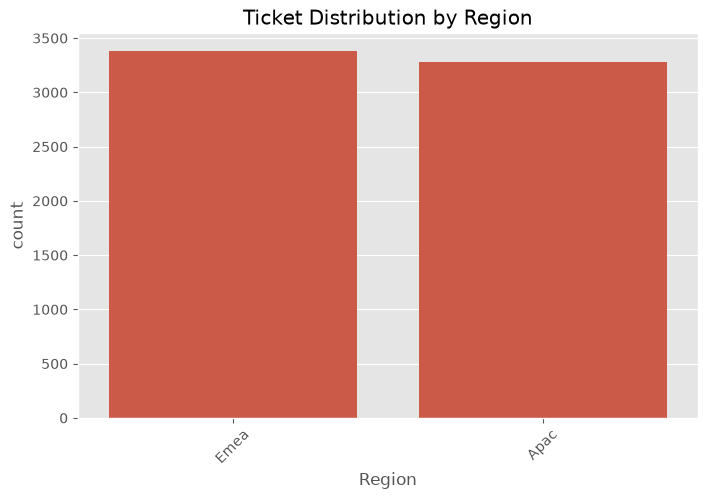

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Region",
    order=df["Region"].value_counts().index
)

plt.title("Ticket Distribution by Region")
plt.xticks(rotation=45)

plt.show()

A bar chart showing ticket counts by region.

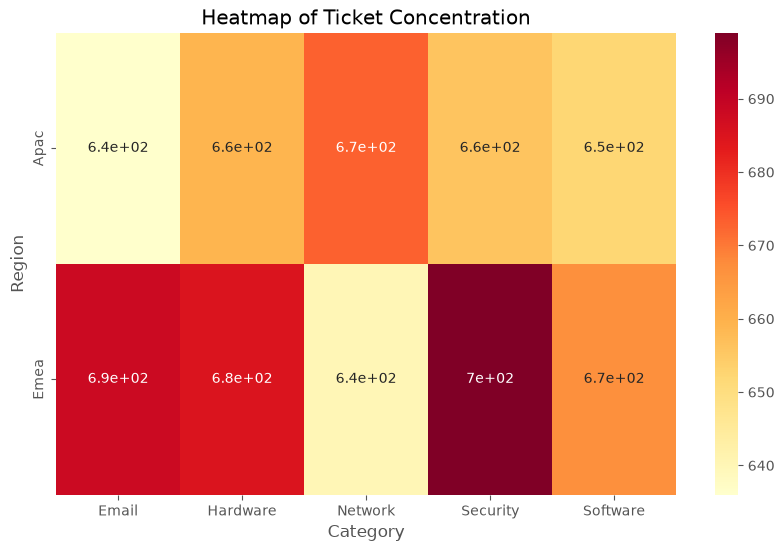

In [25]:
region_category = pd.crosstab(
    df["Region"],
    df["Category"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    region_category,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Heatmap of Ticket Concentration")

plt.show()

Colored heatmap showing ticket counts

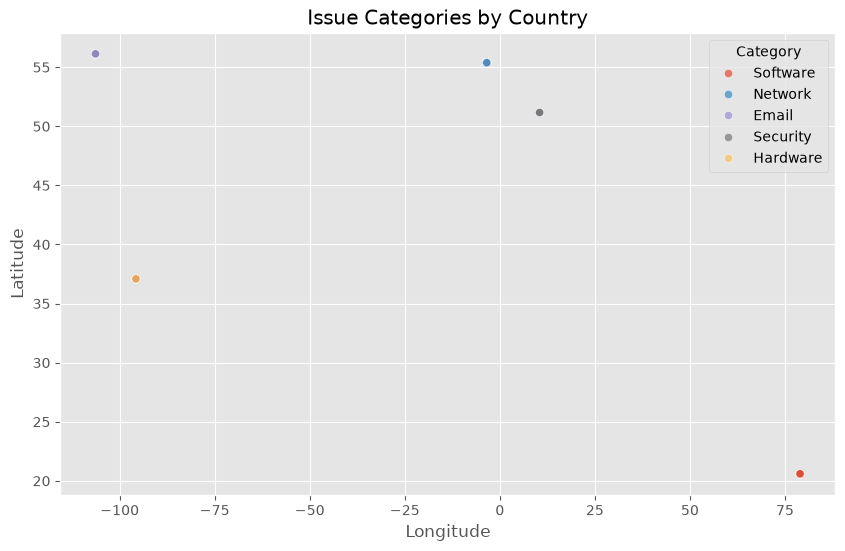

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Category",
    alpha=0.7
)

plt.title("Issue Categories by Country")

plt.show()

Countries plotted geographically with different colors for each issue category.

In [27]:
cluster_size = (
    df.groupby("Cluster_ID")
      .size()
      .reset_index(name="Cluster_Size")
)

cluster_size.head()

,Cluster_ID,Cluster_Size
0,Cl001,3359
1,Cl002,3301
2,Cl003,3340


In [28]:
performance = (
    df.groupby("Cluster_ID")["Similarity_Score"]
      .mean()
      .reset_index(name="Performance_Score")
)

performance.head()

,Cluster_ID,Performance_Score
0,Cl001,0.743459
1,Cl002,0.743747
2,Cl003,0.746644


In [29]:
cluster_performance = cluster_size.merge(
    performance,
    on="Cluster_ID"
)

cluster_performance.head()

,Cluster_ID,Cluster_Size,Performance_Score
0,Cl001,3359,0.743459
1,Cl002,3301,0.743747
2,Cl003,3340,0.746644


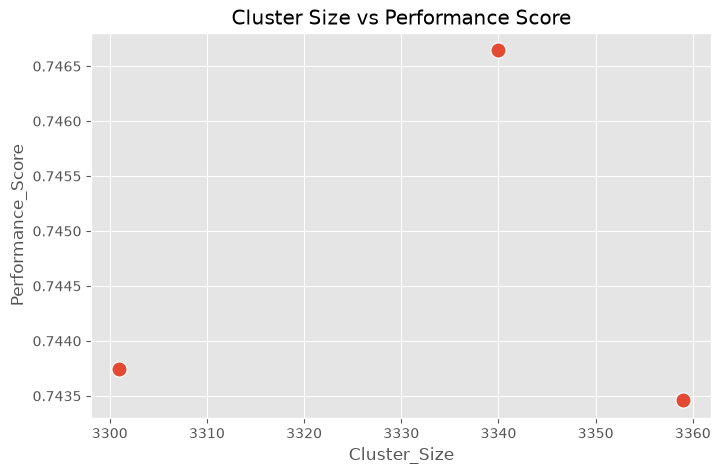

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cluster_performance,
    x="Cluster_Size",
    y="Performance_Score",
    s=120
)

plt.title("Cluster Size vs Performance Score")

plt.show()

Scatter plot showing cluster size versus average similarity score.

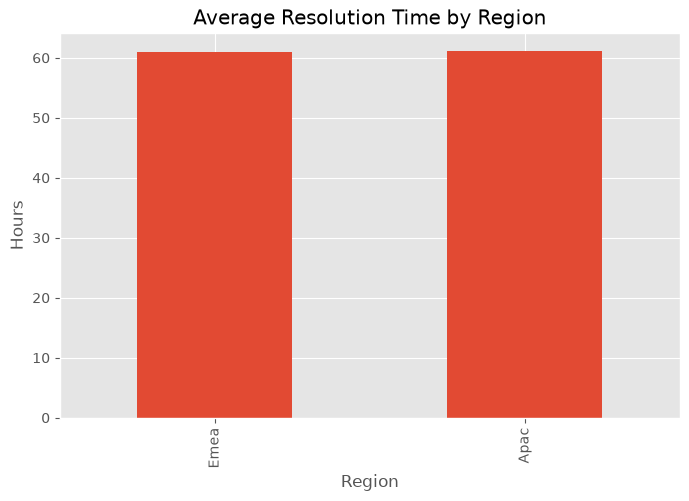

In [31]:
region_resolution = (
    df.groupby("Region")["Resolution_Duration"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8,5))

region_resolution.plot(kind="bar")

plt.ylabel("Hours")

plt.title("Average Resolution Time by Region")

plt.show()

Bar chart of average resolution duration.

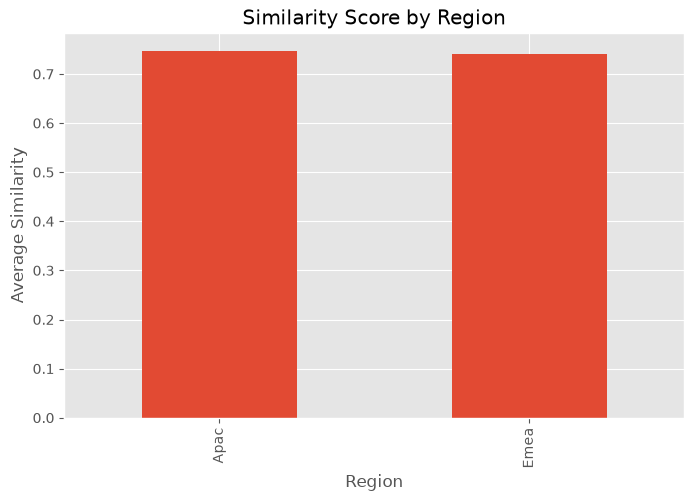

In [32]:
similarity = (
    df.groupby("Region")["Similarity_Score"]
      .mean()
)

plt.figure(figsize=(8,5))

similarity.plot(kind="bar")

plt.ylabel("Average Similarity")

plt.title("Similarity Score by Region")

plt.show()

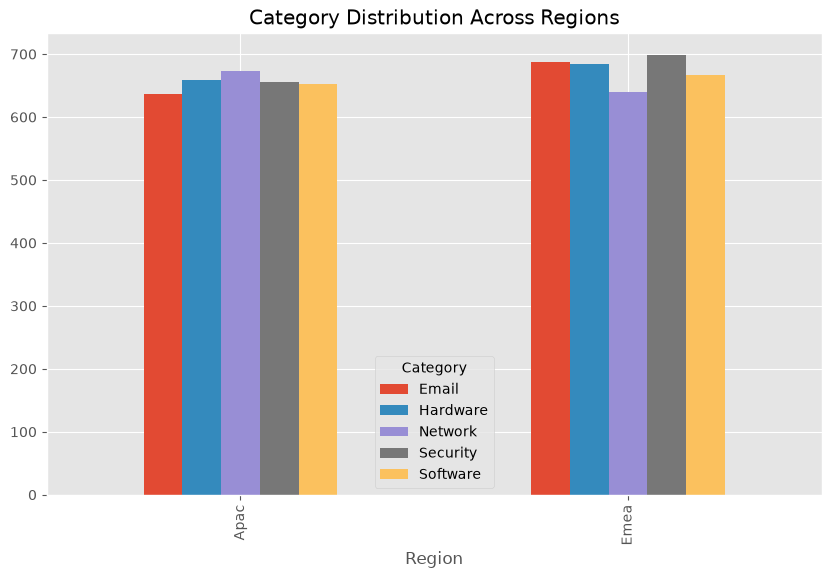

In [33]:
category_region = pd.crosstab(
    df["Region"],
    df["Category"]
)

category_region.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Category Distribution Across Regions")

plt.show()

In [34]:
summary = pd.DataFrame({
    "Metric":[
        "Total Tickets",
        "Average Resolution Time",
        "Average Similarity",
        "Number of Regions",
        "Number of Clusters"
    ],
    "Value":[
        len(df),
        round(df["Resolution_Duration"].mean(),2),
        round(df["Similarity_Score"].mean(),2),
        df["Region"].nunique(),
        df["Cluster_ID"].nunique()
    ]
})

summary

,Metric,Value
0,Total Tickets,10000.00
1,Average Resolution Time,61.10
2,Average Similarity,0.74
3,Number of Regions,2.00
4,Number of Clusters,3.00


# Summary

This module analyzes the geographic distribution and category-level insights of IT support tickets. Various visualizations were created to understand regional ticket concentration, cluster performance, and operational efficiency. Geographic mapping and comparative analysis help identify trends and support better decision-making.

# Tasks Completed

- Loaded the cleaned IT support dataset.
- Verified geographic and categorical data.
- Generated Latitude and Longitude values using the Country column.
- Created a heatmap of ticket concentration by region.
- Developed a geographic scatter plot using Latitude and Longitude.
- Calculated cluster sizes for all ticket clusters.
- Computed average similarity scores for each cluster.
- Compared cluster size with performance score using scatter plots.
- Analyzed average resolution time by region.
- Compared similarity scores across different regions.
- Created comparative charts for regional analysis.
- Generated a performance metrics summary.

# Key Findings

- Ticket volumes vary across different regions.
- Some issue categories are more common in specific geographic locations.
- Regions with lower average resolution times perform more efficiently.
- Cluster size does not always indicate better performance.
- Similarity scores provide insights into cluster quality.
- Geographic visualizations make regional ticket patterns easier to understand.
- Comparative charts highlight opportunities for improving IT support operations.

# Conclusion

Module 6 successfully analyzed geographic and category-level insights of IT support tickets using data visualization techniques. Heatmaps, geographic mapping, and comparative charts helped identify regional trends, evaluate cluster performance, and assess operational efficiency. The insights generated from this module can support better resource allocation, faster issue resolution, and improved IT support services.